Example code is obtained on PyTorch-Deeplabv3: https://pytorch.org/hub/pytorch_vision_deeplabv3_resnet101/

In [1]:
import torchvision
import sys
import os
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, recall_score, precision_score
import pandas as pd
import time
import numpy as np

In [2]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'deeplabv3_resnet50', pretrained=True)
# or any of these variants
# model = torch.hub.load('pytorch/vision:v0.10.0', 'deeplabv3_resnet101', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'deeplabv3_mobilenet_v3_large', pretrained=True)
model.eval()


Using cache found in C:\Users\syj43/.cache\torch\hub\pytorch_vision_v0.10.0
c:\Users\syj43\anaconda3\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\syj43\anaconda3\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu):

In [3]:
def get_img_ready(file):
    input_image = Image.open(file)
    input_image = input_image.convert("RGB")
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    input_tensor = preprocess(input_image)
    input_batch = input_tensor.unsqueeze(0) # create a mini-batch as expected by the model

    # move the input and model to GPU for speed if available
    if torch.cuda.is_available():
        input_batch = input_batch.to('cuda')
        model.to('cuda')

    with torch.no_grad():
        output = model(input_batch)['out'][0]
    output_predictions = output.argmax(0)
    return input_image, output_predictions

In [4]:
# create a color pallette, selecting a color for each class
palette = torch.tensor([2 ** 25 - 1, 2 ** 15 - 1, 2 ** 21 - 1])
colors = torch.as_tensor([i for i in range(21)])[:, None] * palette
colors = (colors % 255).numpy().astype("uint8")

In [5]:
np.random.seed(3)

def show_pil_mask( # draw image with annotations
    image: Image.Image, 
    mask: Image.Image, 
    borders: bool = True, 
    alpha: float = 0.5, 
    color: tuple = None
):
    """Draw an image with annotations"""
    # 1. Convert PIL image to RGBA float array [0.0, 1.0] for blending
    img_rgb = image.convert("RGB")
    img_np = np.array(img_rgb, dtype=np.float32) / 255.0
    
    # 2. Convert PIL mask to boolean NumPy array
    mask_np = np.array(mask.convert("L")) > 0

    if not mask_np.any():
        print("Mask is empty.")
        plt.imshow(img_rgb)
        return

    # 3. Choose or generate a color
    if color is None:
        color = np.random.random(3)  # Random RGB values in range [0.0, 1.0]
    else:
        color = np.array(color)

    # 4. Blend mask color with the original image
    # Blend formula: Pixel = Pixel * (1 - alpha) + Color * alpha
    img_np[mask_np] = img_np[mask_np] * (1 - alpha) + color * alpha

    # 5. Optionally draw smooth contour borders
    if borders:
        # OpenCV needs uint8 mask (0 or 255)
        binary_mask = mask_np.astype(np.uint8)
        
        # Find external contours
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        
        # Smooth contours using approxPolyDP
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        
        # Draw solid contour borders (Color: Blue/Cyan blend or customized)
        border_color = (0, 0, 1)  # Pure Blue in RGB (float range [0, 1])
        cv2.drawContours(img_np, contours, -1, border_color, thickness=2)

    # 6. Display using Matplotlib
    ax = plt.gca()
    ax.imshow(img_np)
    ax.axis("off")  # Hide coordinate axes for a clean visualization

In [6]:
def get_metrics(labels, idx, pred):
    y_true = labels[idx].astype(int).ravel()
    y_pred = pred
    accuracy = round(accuracy_score(y_true, y_pred), 3)
    iou = round(jaccard_score(y_true, y_pred, average='macro',  zero_division=1), 3)
    precision = round(precision_score(y_true, y_pred, average='macro', zero_division=1), 3)
    recall = round(recall_score(y_true, y_pred, average='macro', zero_division=1), 3)
    f1 = round(f1_score(y_true, y_pred, average='macro',  zero_division=1), 3)
    return [accuracy, iou, precision, recall, f1]

def add_highest_iou(labels, preds, idx):
    y_true = labels[idx].astype(int).ravel()

    l_pred, l_iou = [], []
    for i in np.unique(preds[idx]):
        y_pred = (np.array(preds[idx]) == i).astype(int).ravel()
        iou = round(jaccard_score(y_true, y_pred, average='macro',  zero_division=1), 3)
        l_pred.append(y_pred)
        l_iou.append(iou)
        
    best_idx = np.argmax(l_iou)
    l_metrics = get_metrics(labels, idx, l_pred[best_idx])
    return l_metrics

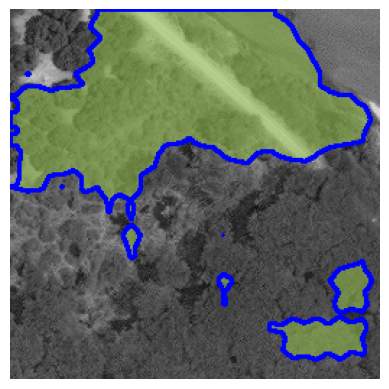

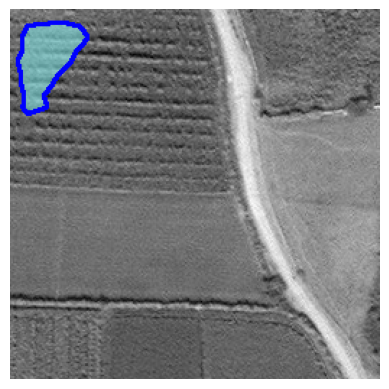

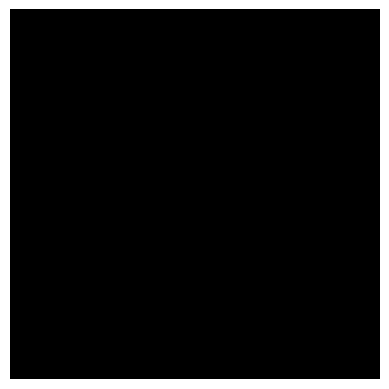

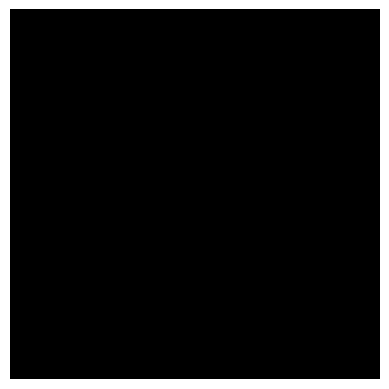

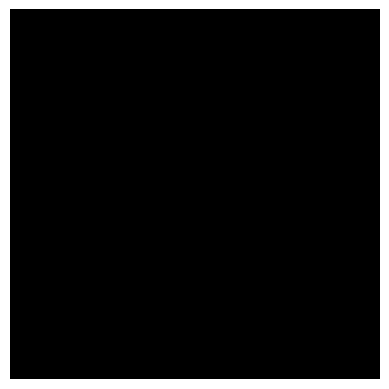

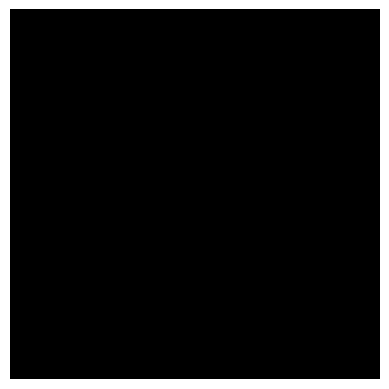

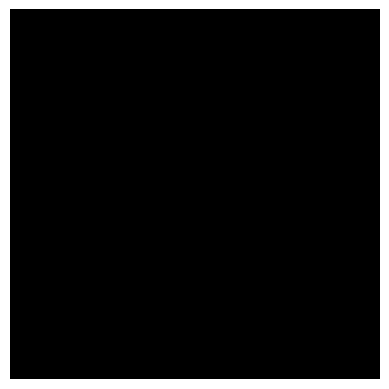

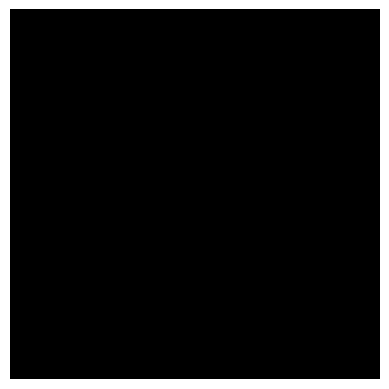

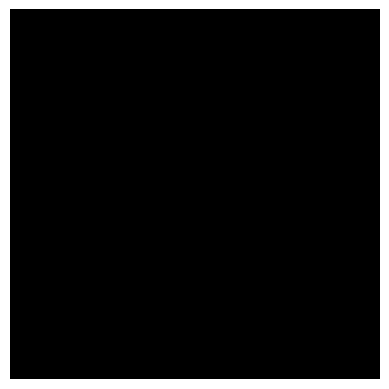

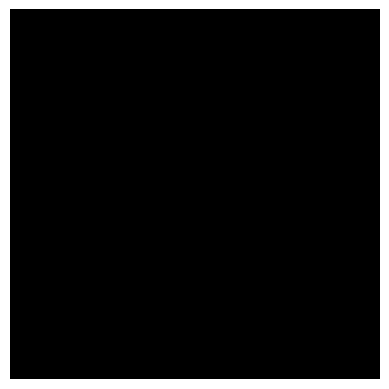

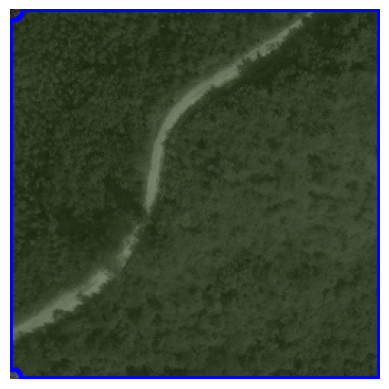

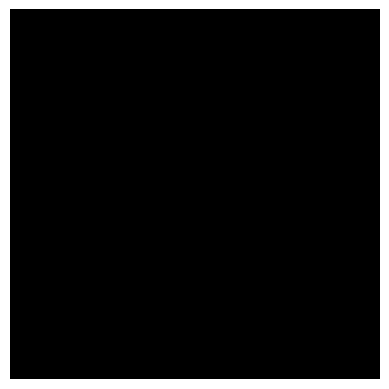

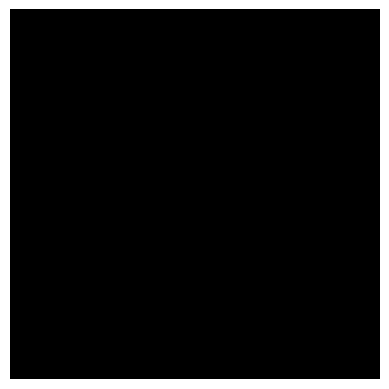

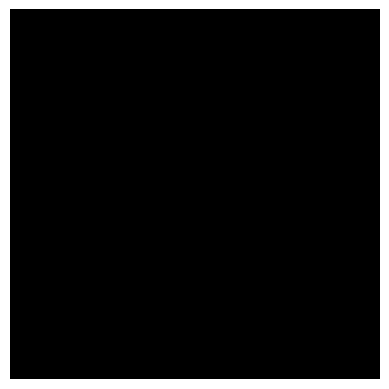

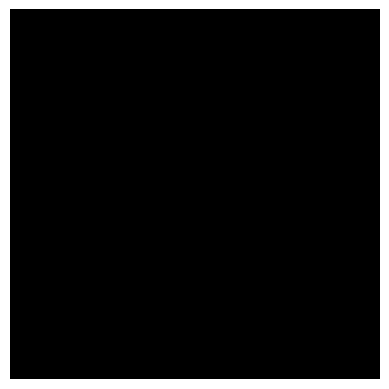

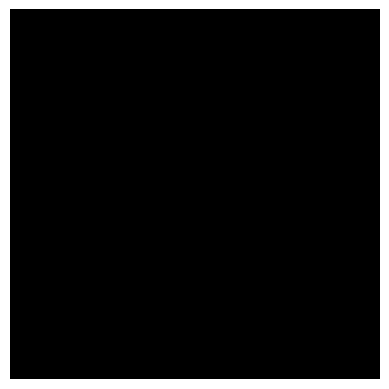

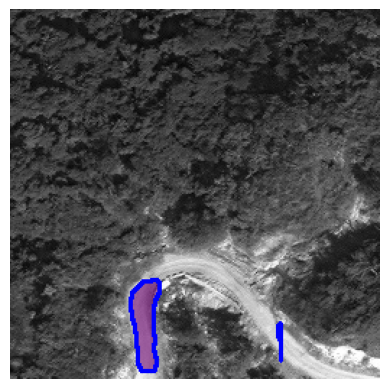

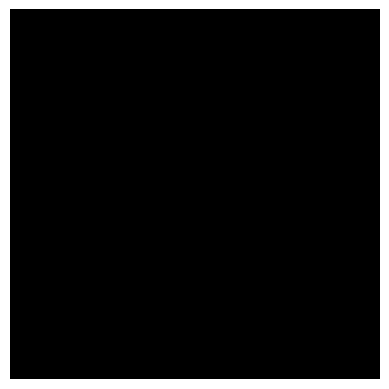

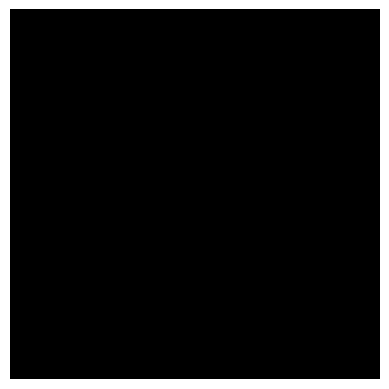

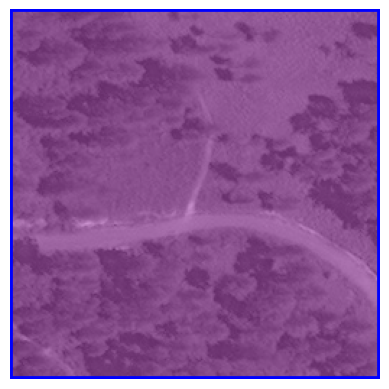

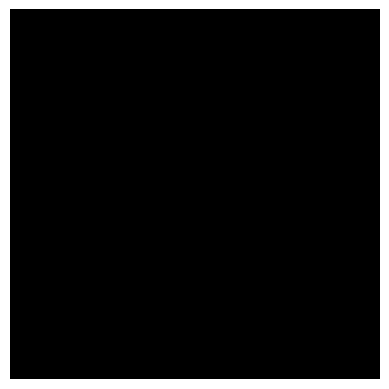

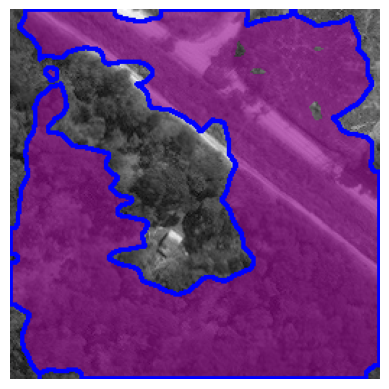

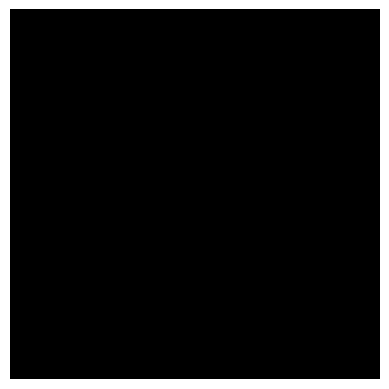

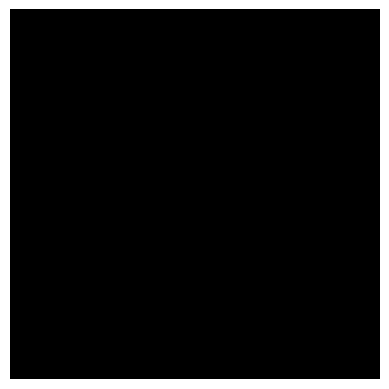

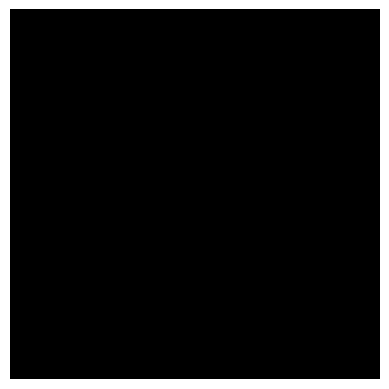

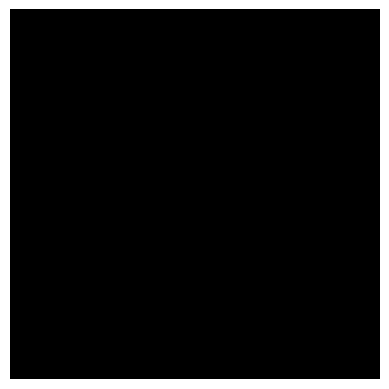

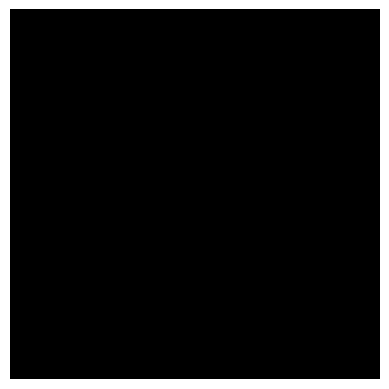

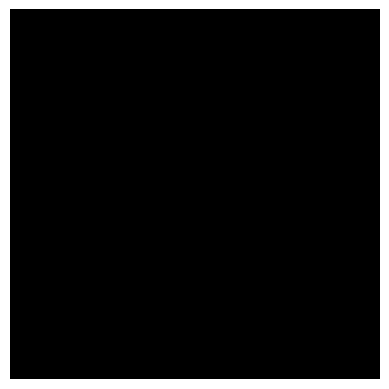

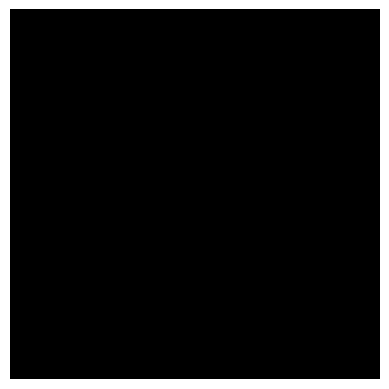

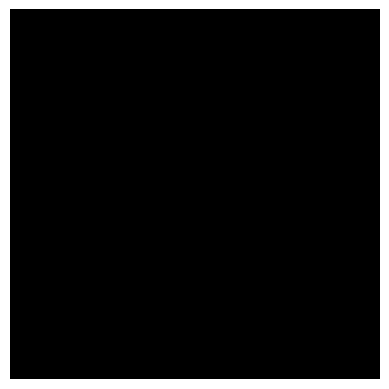

In [7]:
img_path = "C:/Users/syj43/q_seg/datasets/road_test/images/"
label_path = "C:/Users/syj43/q_seg/datasets/road_test/labels/"
img_files = [f for f in os.listdir(img_path) if f.endswith("_sat.jpg") or f.endswith("_sat.png")]
label_files = [f for f in os.listdir(label_path) if f.endswith("_mask.jpg") or f.endswith("_mask.png")] # ground truth

df = pd.DataFrame(columns=['idx', 'Accuracy', 'IoU', 'Precision', 'Recall', 'F1', 'Runtime'])

images, preds, labels = [], [], []
for i in range(len(img_files)):
    start = time.time()
    input_image, output_predictions = get_img_ready(img_path + img_files[i])
    end = time.time()
    
    r = Image.fromarray(output_predictions.byte().cpu().numpy()).resize(input_image.size)
    r.putpalette(colors)
    images.append(input_image)
    preds.append(r)
    
    if np.all(np.array(preds[i]).ravel()==0): # empty mask
        plt.imshow(r)
        plt.axis('off')
        plt.show()
    else:
        show_pil_mask(images[i], preds[i], borders=True, alpha=0.6)
        plt.show()
    
    label = cv2.imread(label_path + label_files[i], cv2.IMREAD_GRAYSCALE) / 255.0
    labels.append(label)
    
    df.loc[len(df)] = [i] + add_highest_iou(labels, preds, i) + [round(end-start,3)]

In [8]:
df.to_csv('road_deeplab.csv', index=False)

In [9]:
df.describe().loc[['mean', '50%']].round(3)

,idx,Accuracy,IoU,Precision,Recall,F1,Runtime
mean,14.5,0.188,0.103,0.543,0.515,0.133,0.166
50%,14.5,0.052,0.026,0.524,0.500,0.049,0.163


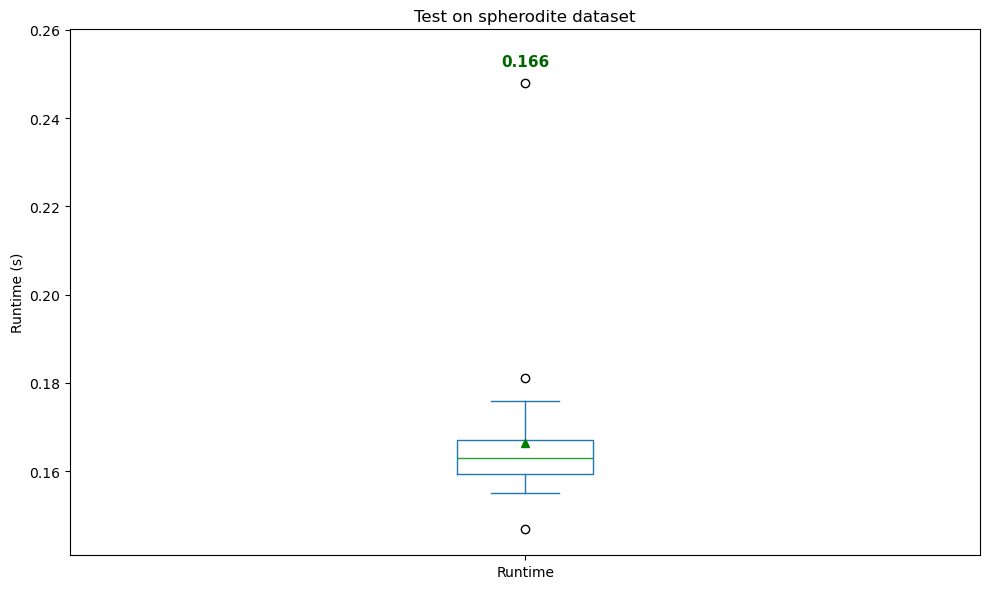

In [10]:
if 'idx' in df.columns:
    df_runtime = df.set_index('idx')

df_runtime = df_runtime[['Runtime']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

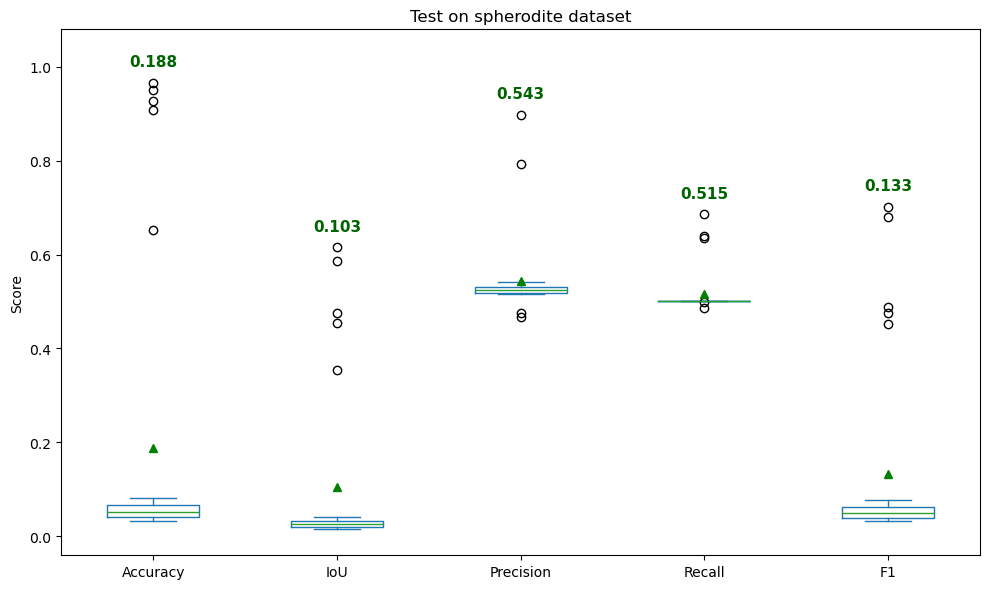

In [11]:
df.drop(columns=['idx', 'Runtime'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df.values.max() - df.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df.columns, start=1):
    mean_val = df[col].mean()
    max_val = df[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df.values.min() - y_offset * 2, df.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()